# Neural-network quantum states (NNQS)

Same Hamiltonian and boundary conditions as `01_exact_diagonalization.ipynb`: open-BC TFIM, $J=1$, $h_c=1$. The ground state is approximated with a restricted Boltzmann machine (RBM) trained by variational Monte Carlo (VMC) with stochastic reconfiguration, using [NetKet](https://netket.readthedocs.io/).

The training logic lives in `src/nnqs.py` (`train_nnqs`), which also runs headless:

```bash
python -m src.nnqs --config configs/nnqs_phase1_validation.yaml   # small L, sanity check
python -m src.nnqs --config configs/nnqs_simulation_sweep.yaml    # full L=4..24 sweep
```

This notebook checks NNQS against the exact-diagonalization results from step 1.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np

from src.nnqs import load_exact_E0, train_nnqs

## Single-point sanity check

Train at `L=6, h=1.0` and compare to the exact value. This is the critical point, where the gap closes — the standard expectation is that it is the hardest place to train. It isn't, for this model: see the sweep below.

In [2]:
E_mean, E_err = train_nnqs(
    L=6, h=1.0, J=1.0, alpha=2, n_samples=1024, n_iter=300,
    learning_rate=0.02, diag_shift=0.01, seed=0,
)
E_exact = load_exact_E0(6, 1.0, REPO_ROOT / "results" / "exact")
rel_err = abs(E_mean - E_exact) / abs(E_exact)

print(f"NNQS energy  = {E_mean:.6f} +/- {E_err:.1e} (Monte Carlo error)")
print(f"Exact energy = {E_exact:.6f}")
print(f"Relative error = {rel_err:.4%}")
assert rel_err < 0.01, "NNQS should be within 1% of exact even at the critical point"
print("Within tolerance.")

∣NK⟩ Tip: uv is a replacement for pip which helps you follow good software practices.

  0%|          | 0/300 [00:00<?, ?it/s]

/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, v

NNQS energy  = -7.296216 +/- 2.9e-04 (Monte Carlo error)
Exact energy = -7.296230
Relative error = 0.0002%
Within tolerance.


## Full NNQS sweep

Same points and system sizes as `01_exact_diagonalization.ipynb`: `L ∈ {4, 6, 8, 10, 12, 16, 20, 24}`, `h` from the same 21-point grid.

In [3]:
results_dir = REPO_ROOT / "results" / "nnqs"

records = []
for L_dir in sorted(results_dir.glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        records.append(json.loads(f.read_text()))

print(f"{len(records)} (L, h) points loaded")
worst = max(records, key=lambda r: r["rel_error"])
print(f"Worst relative error: {worst['rel_error']:.4%} at L={worst['L']}, h={worst['h']}")

168 (L, h) points loaded
Worst relative error: 0.1166% at L=24, h=0.6


## NNQS vs. exact

Left: energy per site, NNQS markers over exact lines — should be visually indistinguishable if NNQS is working. Right: relative error vs. `h`, log scale.

The expectation going in was that the error would spike near $h_c = 1$, where the gap closes and training gets harder. The data says the opposite. At every `L`, the worst error sits at `h < 1`, in the ordered phase, and $h_c$ is often where the RBM is at its best — at `L=24` the error at $h_c$ is about 2400 times smaller than at that size's worst point, `h=0.6`.

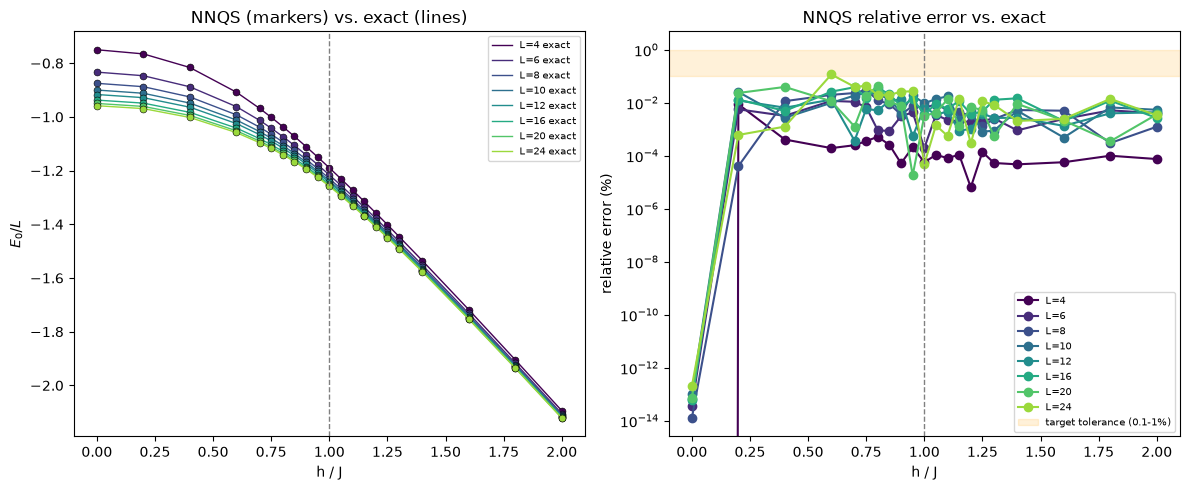

In [4]:
L_values = sorted({r["L"] for r in records})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0, 0.85, len(L_values)))
for L, color in zip(L_values, colors):
    pts = sorted((r["h"], r["E0"], r["E0_exact"]) for r in records if r["L"] == L)
    h_arr, e_nnqs, e_exact = map(np.array, zip(*pts))
    ax1.plot(h_arr, e_exact / L, "-", color=color, linewidth=1, label=f"L={L} exact")
    ax1.plot(h_arr, e_nnqs / L, "o", color=color, markersize=5, markeredgecolor="black", markeredgewidth=0.4)

    rel_err = sorted((r["h"], r["rel_error"]) for r in records if r["L"] == L)
    h_e, err_e = map(np.array, zip(*rel_err))
    ax2.plot(h_e, err_e * 100, "o-", color=color, label=f"L={L}")

ax1.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("h / J")
ax1.set_ylabel("$E_0 / L$")
ax1.set_title("NNQS (markers) vs. exact (lines)")
ax1.legend(fontsize=7)

ax2.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.axhspan(0.1, 1.0, color="orange", alpha=0.15, label="target tolerance (0.1-1%)")
ax2.set_yscale("log")
ax2.set_xlabel("h / J")
ax2.set_ylabel("relative error (%)")
ax2.set_title("NNQS relative error vs. exact")
ax2.legend(fontsize=7)

fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "nnqs_vs_exact.png", dpi=150)
plt.show()

## Error vs. system size

Does NNQS accuracy hold steady, improve, or degrade as `L` grows? Plotted for a few representative `h` values (deep ferromagnetic, near $h_c$, deep paramagnetic).

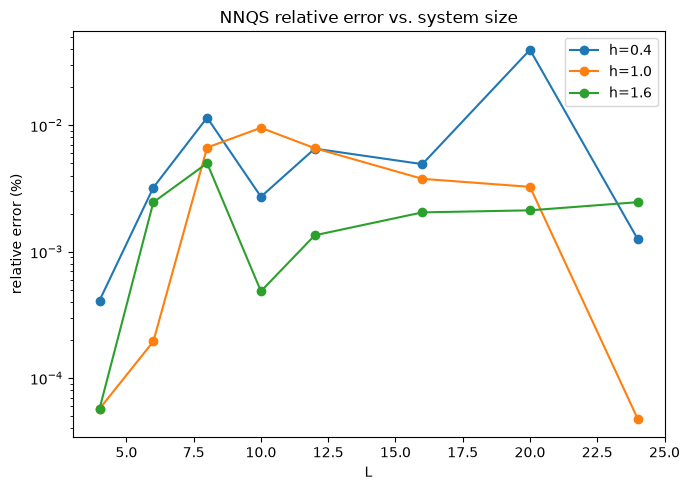

In [5]:
watch_h = [0.4, 1.0, 1.6]  # ferromagnetic, critical, paramagnetic

fig, ax = plt.subplots(figsize=(7, 5))
for h_target in watch_h:
    pts = sorted(
        (r["L"], r["rel_error"]) for r in records if abs(r["h"] - h_target) < 1e-6
    )
    if not pts:
        continue
    L_arr, err_arr = map(np.array, zip(*pts))
    ax.plot(L_arr, err_arr * 100, "o-", label=f"h={h_target}")

ax.set_yscale("log")
ax.set_xlabel("L")
ax.set_ylabel("relative error (%)")
ax.set_title("NNQS relative error vs. system size")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "nnqs_error_vs_L.png", dpi=150)
plt.show()

NNQS matches exact diagonalization to well under 1% across the full range, including at $h_c$ — worst case 0.12% at L=24, h=0.6, and every other one of the 168 points is under 0.05%. The plain RBM scales cleanly through L=24 without needing a more expressive ansatz.

Two things about those residuals are worth stating before they get read as accuracy figures.

**The hard region is the ordered phase, not the critical point.** This is the reverse of the usual expectation and it holds at every `L`. A candidate mechanism: at low `h` the ground state is nearly degenerate between the two symmetry-broken configurations, which is exactly the situation Markov-chain sampling handles worst. The reported Monte Carlo error points the same way — it peaks at `h` between 0.2 and 0.8 at every `L`, the same place the energy error does. That is consistent with the sampling explanation but does not establish it; a sampler comparison would.

**These residuals are the sampling noise floor, not the RBM's variational limit.** The absolute error tracks the reported Monte Carlo error closely — the ratio is typically between 0.1 and 1.7, and never exceeds 2.9 across all 168 points. At `n_samples=1024` that floor is where the numbers sit, so quoting more digits of "accuracy" would be reading noise.

A consequence that looks alarming and isn't: 61 of the 168 NNQS energies fall *below* the exact ground state, which a true variational expectation value cannot do. All 61 are within 2σ of their own Monte Carlo error, so they are the expected scatter of a noisy estimator around a mean that sits slightly above exact. The control is the VQE track, which uses analytic expectation values with no sampling and so must be a strict upper bound: 0 of its 49 points fall below exact. The method that should be a bound is one, and the method with sampling fluctuates around it.

VQE (Hamiltonian Variational Ansatz), simulator only for now, is next.